In [1]:
%reload_ext autoreload
%autoreload 2

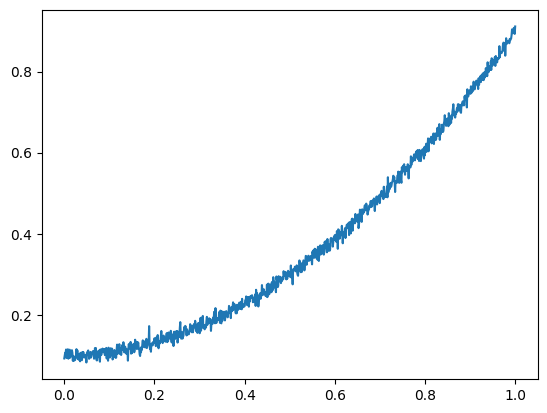

In [64]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from flax import nnx

from probjax.nn import MLP

X = np.linspace(0, 1, 1000)[:, None]
Y = 0.8 * X**2 + 0.1 + np.random.normal(0, 0.1, size=X.shape)*0.1
plt.plot(X,Y)

In [65]:
model = MLP([1,50,50,1], rngs=nnx.Rngs(0))
nnx.display(model)

In [66]:
def logdenstiy_fn(model):
    y = model(X)
    return -0.5*jnp.sum((Y - y)**2)/0.5**2 - jax.tree_util.tree_reduce(lambda x, y: jnp.sum(y**2) + jnp.sum(y**2), model) # With prior


In [73]:
jax.jit(logdenstiy_fn)(model)

Array(-1890.7545, dtype=float32)

In [79]:
import jax

from probjax.inference.mcmc import hmc
from probjax.inference.mcmc_runner import MCMC

kernel = hmc(logdenstiy_fn)

state = kernel.init(model)
params = kernel.init_params(model, step_size=1e-3)

In [75]:
mcmc = MCMC(kernel, verbose=True)

In [76]:
state = mcmc.run(jax.random.PRNGKey(0), state, 10_000, params)

In [80]:
samples = mcmc.sample(jax.random.PRNGKey(1), state, 1000, params, thin=50)

KeyboardInterrupt: 

(-0.5, 1.5)

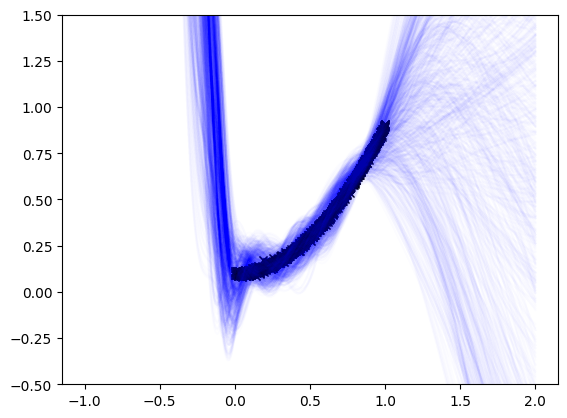

In [78]:
def predict(model, X):
    return model(X)
X_test = np.linspace(-1, 2, 300)[:, None]
preds = jax.vmap(predict, in_axes=(0, None))(samples[0], X_test)
plt.plot(X, Y, 'kx')
_ = plt.plot(X_test, preds[...,0].T, 'b', alpha=0.01)
plt.ylim(-0.5, 1.5)